# **AAI 521 - Group 7 Final Project EDA + Preprocessing**

Contributers: Christopher Mendoza, Payal Patel, Tommy Poole

- Goal: Develop a simplified “SLAM-Lite” visual mapping pipeline using the GrapeSLAM UAV dataset that reconstructs a 3D scene and estimates the drone’s path from monocular camera images.

- Learning Objective: Apply computer vision (feature detection, optical flow, pose estimation) to autonomous navigation challenges.


### Import + Paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, cv2, json, math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pathlib import Path
from moviepy.editor import VideoFileClip

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



In [2]:
# Define paths (Keeping it consistent with Christopher's to keep things cohesive)
DRIVE_BASE = "/content/drive/MyDrive/SLAM_Lite"
DATA_DIR = f"{DRIVE_BASE}/zenodo_14979685"

# One cache root for my work
CACHE_R = f"{DRIVE_BASE}/eda_pat"
os.makedirs(CACHE_R, exist_ok=True)

print("Directory: ", DATA_DIR)
print("Cache Directory: ", CACHE_R)

# All .MOV files
all_files = sorted(glob.glob(os.path.join(DATA_DIR, "**/*.*"), recursive=True))
MOV_files = [f for f in all_files if f.lower().endswith(".mov")]

print(f"Found {len(MOV_files)} videos")
for i, f in enumerate(MOV_files):
  print(f"[{i}] {os.path.basename(f)}")

Directory:  /content/drive/MyDrive/SLAM_Lite/zenodo_14979685
Cache Directory:  /content/drive/MyDrive/SLAM_Lite/eda_pat
Found 24 videos
[0] DJI_0016.MOV
[1] DJI_0018.MOV
[2] DJI_0019.MOV
[3] DJI_0027.MOV
[4] DJI_0028.MOV
[5] DJI_0029.MOV
[6] DJI_0032.MOV
[7] DJI_0033.MOV
[8] DJI_0034.MOV
[9] DJI_0037.MOV
[10] DJI_0038.MOV
[11] DJI_0042.MOV
[12] DJI_0044.MOV
[13] DJI_0046.MOV
[14] DJI_0047.MOV
[15] DJI_0048.MOV
[16] DJI_0049.MOV
[17] DJI_0051.MOV
[18] DJI_0054.MOV
[19] DJI_0056.MOV
[20] DJI_0058.MOV
[21] DJI_0059.MOV
[22] DJI_0060.MOV
[23] DJI_0061.MOV


In [3]:
# Chose a flight
FLIGHT_IDX = 2
VIDEO_PATH = MOV_files[FLIGHT_IDX]
print("Chose: ", VIDEO_PATH)

Chose:  /content/drive/MyDrive/SLAM_Lite/zenodo_14979685/DJI_0019.MOV


## EDA + Preprocessing (Cached)

###Load Frames from Video

In [4]:
def load_frames(VIDEO_PATH, max_frames=None, resize=(224, 224)):
  """
  Loads videp frames and normalizes them for processing.
  To speed up VO and EDA we use max_frames.
  We resize the frames to stay consistent
  Convert BGR to RGB and rescale to [0, 1]
  """
  vid_cap = cv2.VideoCapture(VIDEO_PATH)
  frames = []
  total_frames = int(vid_cap.get(cv2.CAP_PROP_FRAME_COUNT))

  # Stride to reduce frame count
  stride = 1 if (max_frames is None or max_frames >= total_frames) else max(1, total_frames // max_frames)

  idx = 2
  while True:
    r, frame = vid_cap.read()
    if not r:
      break

    # Only keep the frames that are chosen at stride interval
    if idx % stride == 2:
      resized_frame = cv2.resize(frame, resize)
      rgb_frame = cv2.cvtColor(resized_frame, cv2.COLOR_BGR2RGB)
      norm_frame = rgb_frame / 255.0
      frames.append(norm_frame)

    idx += 1

  vid_cap.release()
  frames = np.stack(frames, axis=0)
  return frames

### Convert RGB -> Grayscale

In [5]:
def gray(rgb_frame):
  """
  Convert RGB float32 image into grayscale float32.
  SLAM uses grayscale frames.
  """
  gray_frame = cv2.cvtColor((rgb_frame * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
  return gray_frame.astype(np.float32) / 255.0

### Compute EDA Metrics

In [6]:
def frame_metrics(frames):
  """
  For each frame, we compute the following:
  - Lighting
  - Laplacian
  - ORB feature count
  """
  metric = []
  orb = cv2.ORB_create(nfeatures=1000)

  for i, frame in enumerate(frames):
    gray_s = gray(frame)

    # Lighting
    light_f = float(np.var(gray_s))

    # Laplacian
    lap_f = cv2.Laplacian((gray_s * 255).astype(np.uint8), cv2.CV_64F)
    tex_f = float(lap_f.var())

    # ORB feature
    kpts = orb.detect((gray_s * 255).astype(np.uint8), None)
    feature_count = len(kpts)

    metric.append({
        "frame_idx" : i,
        "lighting": light_f,
        "texture": tex_f,
        "feature_count": feature_count,
        })
  return pd.DataFrame(metric)

### Create Frame Pairs for VO

In [7]:
def frame_pairs(num_frames, step=1):
  """
  Create frame index pairs (we need this for feature tracking and pose estimation)
  """
  return [(i, i + step) for i in range(0, num_frames - step)]

### Plotting Helping for EDA

In [8]:
def plot_metrics(df_metrics, title_pre=""):
  fig, axes = plt.subplots(1, 3, figsize=(15, 4))

  sns.lineplot(ax=axes[0], data=df_metrics, x="frame_idx", y="lighting")
  axes[0].set_title(f"{title_pre} Lighting")

  sns.lineplot(ax=axes[1], data=df_metrics, x="frame_idx", y="texture")
  axes[1].set_title(f"{title_pre} Texture")

  sns.lineplot(ax=axes[2], data=df_metrics, x="frame_idx", y="feature_count")
  axes[2].set_title(f"{title_pre} Feature Count")

  for ax in axes:
    ax.grid(True)
  plt.tight_layout()
  plt.show()

(154, 4)
   frame_idx  lighting       texture  feature_count
0          0  0.058936  31429.914230            760
1          1  0.058201  31229.864068            745
2          2  0.058097  30767.106216            760
3          3  0.057878  31620.461261            744
4          4  0.057584  31468.258409            749


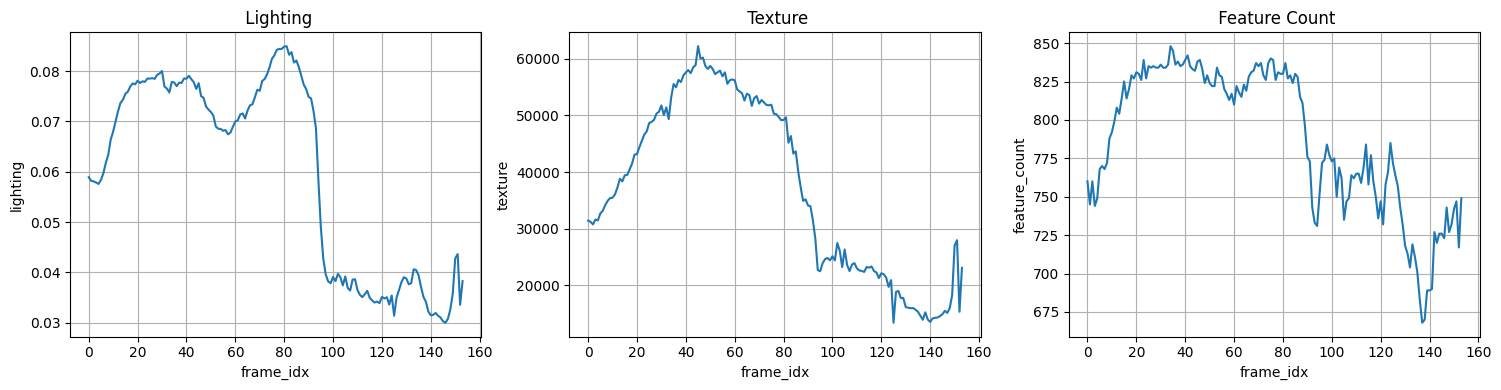

In [9]:
frames = load_frames(VIDEO_PATH, max_frames=150)
df_m = frame_metrics(frames)

print(df_m.shape)
print(df_m.head())

plot_metrics(df_m)


The plots show how lighting, texture, and feature richness change throught the flight. Lighting variance stays relatively stable at the start, increases up to frame 70, and then drops significantly when the drone enters a darker area. Texture follows a similar pattern, peaking early in the flight when the vineyard has more visual detail, then declining as the environment becomes less textured. ORB feature counts also peak duing the high-texture region (around frames 20-80). This indicates strong SLAM-friendly conditions, and then decreases when the scene becomes smoother or less visually distinctive. Overall, these metrics confirm that the first half of the flight provides the best conditions for feature tracking and pose estimation.

###Save EDA Results to Cache

In [10]:
CACHE_DIR = os.path.join(CACHE_R, f"flight_{FLIGHT_IDX:02d}")
os.makedirs(CACHE_DIR, exist_ok=True)

np.save(os.path.join(CACHE_DIR, "frames.npy"), frames)
df_m.to_csv(os.path.join(CACHE_DIR, "metrics.csv"), index=False)

print("Saved")

Saved


In [11]:
# Create pairs
pairs = frame_pairs(len(frames), step=1)
print("Number of frame pairs: ", len(pairs))

# Save pairs
np.save(os.path.join(CACHE_DIR, "pairs.npy"), np.array(pairs))
print("Saved")

Number of frame pairs:  153
Saved


### Check Plot

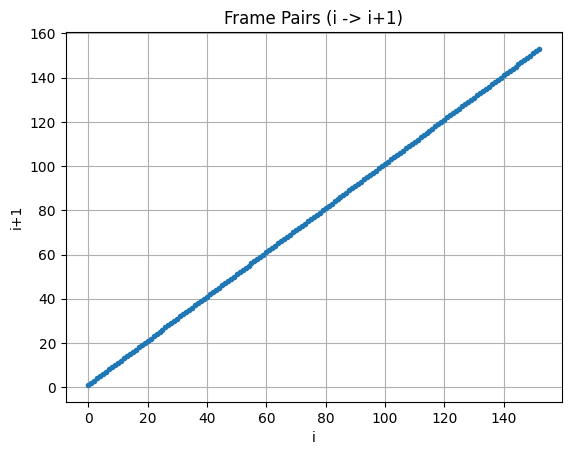

In [12]:
plt.plot([p[0] for p in pairs], [p[1] for p in pairs], '.')
plt.title("Frame Pairs (i -> i+1)")
plt.xlabel("i")
plt.ylabel("i+1")
plt.grid(True)
plt.show()

The frame pair plot shows a linear relationship between each frame index i and paired frame i+1. This confirms that our preprocessing was done correctly. Each point represents a valid transition which is important for comptuing optical flow, tracking features over time, and estimating the motion between frames. This also shows us that there are no missing frames, gaps, and irregularities.

### Sample RGB Frames

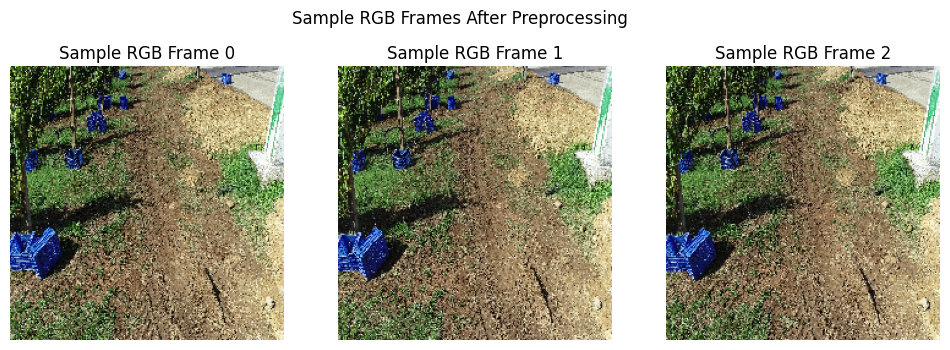

In [13]:
# Visualize a couple RGB Frames
plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(frames[i])
    plt.title(f"Sample RGB Frame {i}")
    plt.axis("off")

plt.suptitle("Sample RGB Frames After Preprocessing")
plt.show()

### Sample Grayscale Frames

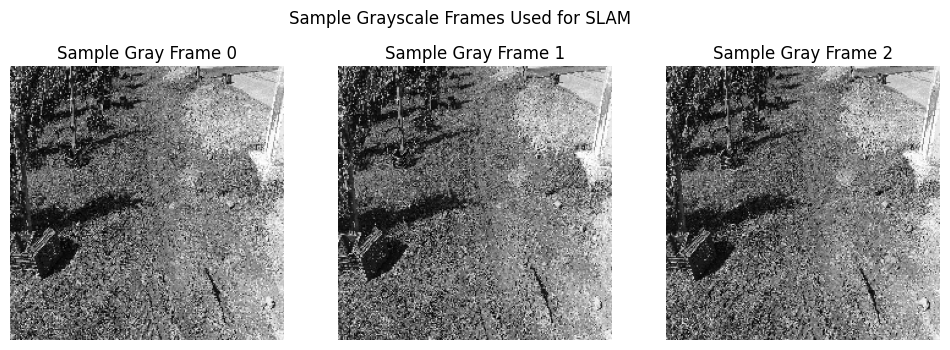

In [14]:
# Visualize a couple grayscale frames
plt.figure(figsize=(12,4))
for i in range(3):
    g = gray(frames[i])
    plt.subplot(1,3,i+1)
    plt.imshow(g, cmap='gray')
    plt.title(f"Sample Gray Frame {i}")
    plt.axis("off")

plt.suptitle("Sample Grayscale Frames Used for SLAM")
plt.show()

### Histogram of Lighting Variance

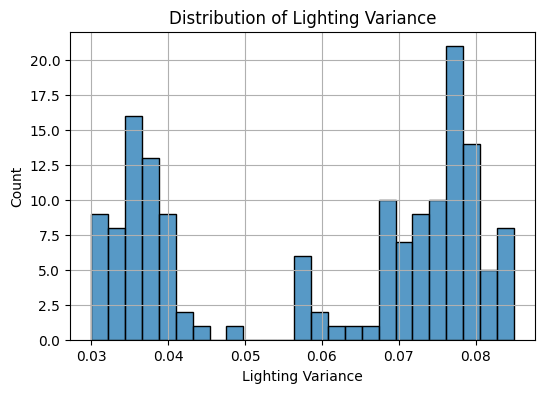

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df_m["lighting"], bins=25)
plt.title("Distribution of Lighting Variance")
plt.xlabel("Lighting Variance")
plt.ylabel("Count")
plt.grid(True)
plt.show()

The lighting variance histogram shows two clusters of brightness levels across the duration of the flight. A large group of frames has a lower variance (around 0.03-0.04), suggesting more uniform lighting (this could be when the drone is over shade or smoother textures). The second cluster around 0.07-0.08 has more brighter lighting conditions with stronger contrast. The separation between the two tells us that the drone likely passed through distinct environmental lighting zones, which is consistent with our line plot showign the drop in brightness mid-flight.

### EDA Summary

In [16]:
print(f"Summary of EDA:")
print(f" - Total number of frames processed: {len(frames)}")
print(f" - Frame resolution: {frames[0].shape}")
print(f" - Number of frames - metrics: {df_m.shape[0]} frames")
print(f" - Number of Frame pairs: {len(pairs)}")
print(f" - Cache directory: {CACHE_DIR}")

Summary of EDA:
 - Total number of frames processed: 154
 - Frame resolution: (224, 224, 3)
 - Number of frames - metrics: 154 frames
 - Number of Frame pairs: 153
 - Cache directory: /content/drive/MyDrive/SLAM_Lite/eda_pat/flight_02
